# ⚛️ Física Geral Experimental — Mecânica & Energia

`Matemática/Ciências` · **Engenharia da Computação** · `Python 3`

> **Cinemática, leis de Newton, trabalho, energia, momento e rotação.**

Mecânica clássica aplicada: movimento, forças, conservação de energia e colisões, com simulações numéricas e gráficos.



## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 CINEMÁTICA

**Ideia:** Descrever o movimento por posição, velocidade, aceleração e gráficos.

- Velocidade: v_m = Δs/Δt; v = ds/dt
- Aceleração: a_m = Δv/Δt; a = dv/dt
- MRU: s = s₀ + v·t
- MRUV: v = v₀ + a·t; s = s₀ + v₀t + a·t²/2
- Torricelli: v² = v₀² + 2a·Δs
- Lançamento: x = v₀cosθ·t; y = v₀senθ·t - g·t²/2

> 💡 **Dica:** Nos gráficos: inclinação de s×t = v; inclinação de v×t = a; área sob v×t = Δs.

### 🟢 DINÂMICA & LEIS DE NEWTON

**Ideia:** Relacionar as forças que atuam no corpo à mudança de seu movimento.

- 2ª lei: ΣF = m·a
- Peso: P = m·g; normal: perpendicular ao contato
- Atrito: f_s ≤ μ_sN; f_k = μ_kN
- Mola: F = -k·x
- Mov. circular: ΣF_rad = m·v²/R = m·ω²R
- Equilíbrio: ΣF_x = 0 e ΣF_y = 0

> 💡 **Dica:** Isole o corpo e faça o diagrama de forças. Força centrípeta não é uma força nova: é a resultante radial.

### 🟢 TRABALHO, ENERGIA & POTÊNCIA

**Ideia:** Acompanhar transferências de energia e prever velocidades sem calcular o tempo.

- Trabalho: W = F·d·cosθ
- Teorema trabalho-energia: W_resultante = ΔK
- Cinética: K = m·v²/2
- Potenciais: U_g = mgh; U_e = kx²/2
- Conservação: K_i + U_i = K_f + U_f (sem dissipação)
- Não conservativas: W_nc = Δ(K + U)
- Potência: Pot = W/Δt = F·v

> 💡 **Dica:** Escolha o nível de U = 0 antes das contas. Com atrito, inclua o trabalho não conservativo.

### 🟢 MOMENTO, COLISÕES & ROTAÇÃO

**Ideia:** Usar leis de conservação para sistemas em translação e rotação.

- Quantidade de movimento: p = m·v
- Impulso: J = ∫F dt = Δp ≈ F_m·Δt
- Conservação: Σp_i = Σp_f, se J_ext ≈ 0
- Colisões: elástica conserva p e K; inelástica conserva p
- Torque: τ = r·F·senθ; Στ = I·α
- Rotação: K_rot = I·ω²/2; L = I·ω
- Rolamento: v = ωR

> 💡 **Dica:** Defina o sistema e o sentido positivo antes de conservar p ou L. Sem impulso/torque externo, o total se mantém.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Fisica_Geral_Experimental_Mecanica_Energia.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFont(TTFont('DVMono', str(FONT_DIR / 'DejaVuSansMono.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette: identical to the previous OneNote sheets ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')
SOFT = HexColor('#C8D1DF')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'CINEMÁTICA',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'cinematica',
        'idea': 'Descrever o movimento por posição, velocidade, aceleração e gráficos.',
        'formulas': [
            '<b>Velocidade:</b> v<sub>m</sub> = Δs/Δt; v = ds/dt',
            '<b>Aceleração:</b> a<sub>m</sub> = Δv/Δt; a = dv/dt',
            '<b>MRU:</b> s = s₀ + v·t',
            '<b>MRUV:</b> v = v₀ + a·t; s = s₀ + v₀t + a·t²/2',
            '<b>Torricelli:</b> v² = v₀² + 2a·Δs',
            '<b>Lançamento:</b> x = v₀cosθ·t; y = v₀senθ·t - g·t²/2',
        ],
        'tip': 'Nos gráficos: inclinação de s×t = v; inclinação de v×t = a; área sob v×t = Δs.',
    },
    {
        'title': 'DINÂMICA &amp;<br/>LEIS DE NEWTON',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'dinamica',
        'idea': 'Relacionar as forças que atuam no corpo à mudança de seu movimento.',
        'formulas': [
            '<b>2ª lei:</b> ΣF = m·a',
            '<b>Peso:</b> P = m·g; <b>normal:</b> perpendicular ao contato',
            '<b>Atrito:</b> f<sub>s</sub> ≤ μ<sub>s</sub>N; f<sub>k</sub> = μ<sub>k</sub>N',
            '<b>Mola:</b> F = -k·x',
            '<b>Mov. circular:</b> ΣF<sub>rad</sub> = m·v²/R = m·ω²R',
            '<b>Equilíbrio:</b> ΣF<sub>x</sub> = 0 e ΣF<sub>y</sub> = 0',
        ],
        'tip': 'Isole o corpo e faça o diagrama de forças. Força centrípeta não é uma força nova: é a resultante radial.',
    },
    {
        'title': 'TRABALHO, ENERGIA<br/>&amp; POTÊNCIA',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'energia',
        'idea': 'Acompanhar transferências de energia e prever velocidades sem calcular o tempo.',
        'formulas': [
            '<b>Trabalho:</b> W = F·d·cosθ',
            '<b>Teorema trabalho-energia:</b> W<sub>resultante</sub> = ΔK',
            '<b>Cinética:</b> K = m·v²/2',
            '<b>Potenciais:</b> U<sub>g</sub> = mgh; U<sub>e</sub> = kx²/2',
            '<b>Conservação:</b> K<sub>i</sub> + U<sub>i</sub> = K<sub>f</sub> + U<sub>f</sub> (sem dissipação)',
            '<b>Não conservativas:</b> W<sub>nc</sub> = Δ(K + U)',
            '<b>Potência:</b> Pot = W/Δt = F·v',
        ],
        'tip': 'Escolha o nível de U = 0 antes das contas. Com atrito, inclua o trabalho não conservativo.',
    },
    {
        'title': 'MOMENTO, COLISÕES<br/>&amp; ROTAÇÃO',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'momento',
        'idea': 'Usar leis de conservação para sistemas em translação e rotação.',
        'formulas': [
            '<b>Quantidade de movimento:</b> p = m·v',
            '<b>Impulso:</b> J = ∫F dt = Δp ≈ F<sub>m</sub>·Δt',
            '<b>Conservação:</b> Σp<sub>i</sub> = Σp<sub>f</sub>, se J<sub>ext</sub> ≈ 0',
            '<b>Colisões:</b> elástica conserva p e K; inelástica conserva p',
            '<b>Torque:</b> τ = r·F·senθ; Στ = I·α',
            '<b>Rotação:</b> K<sub>rot</sub> = I·ω²/2; L = I·ω',
            '<b>Rolamento:</b> v = ωR',
        ],
        'tip': 'Defina o sistema e o sentido positivo antes de conservar p ou L. Sem impulso/torque externo, o total se mantém.',
    },
]

# ---------- layout: identical geometry to the previous sheet ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title',
    fontName='DVCond-Bold',
    fontSize=17.2,
    leading=18.6,
    textColor=WHITE,
    alignment=1,
    spaceAfter=0,
)
STYLE_IDEA = ParagraphStyle(
    'idea',
    fontName='DVCond-Oblique',
    fontSize=12.6,
    leading=15.6,
    textColor=MUTED,
)
STYLE_TIP = ParagraphStyle(
    'tip',
    fontName='DVCond',
    fontSize=11.7,
    leading=14.7,
    textColor=INK,
)


def axis(c, ox, oy, dw, dh):
    ax_y = oy + dh * 0.12
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    c.line(ox, ax_y, ox + dw, ax_y)
    c.line(ox + dw * 0.03, oy, ox + dw * 0.03, oy + dh)
    return ax_y


def arrow(c, x1, y1, x2, y2, color, width=1.2, head=5):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    for delta in (2.55, -2.55):
        c.line(
            x2,
            y2,
            x2 + head * math.cos(ang + delta),
            y2 + head * math.sin(ang + delta),
        )


def diagram_cinematica(c, ox, oy, dw, dh, color):
    ax_y = axis(c, ox, oy, dw, dh)

    # MRU: straight position-time line.
    x0 = ox + dw * 0.07
    x1 = ox + dw * 0.48
    y0 = ax_y + dh * 0.10
    y1 = ax_y + dh * 0.62
    c.setStrokeColor(color)
    c.setLineWidth(1.6)
    c.line(x0, y0, x1, y1)
    c.setFillColor(color)
    c.circle(x1, y1, 2.7, stroke=0, fill=1)

    # MRUV: curved position-time graph.
    p = c.beginPath()
    p.moveTo(ox + dw * 0.53, ax_y + dh * 0.10)
    p.curveTo(
        ox + dw * 0.66,
        ax_y + dh * 0.12,
        ox + dw * 0.78,
        ax_y + dh * 0.30,
        ox + dw * 0.94,
        ax_y + dh * 0.79,
    )
    c.drawPath(p, stroke=1, fill=0)

    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 9.4)
    c.drawCentredString(ox + dw * 0.29, oy + 2, 'MRU')
    c.drawCentredString(ox + dw * 0.73, oy + 2, 'MRUV')

    # Tangent arrow to reinforce instantaneous velocity.
    arrow(
        c,
        ox + dw * 0.72,
        ax_y + dh * 0.28,
        ox + dw * 0.88,
        ax_y + dh * 0.57,
        INK,
        0.9,
        4,
    )


def diagram_dinamica(c, ox, oy, dw, dh, color):
    # Inclined plane.
    x_left = ox + dw * 0.08
    x_right = ox + dw * 0.92
    y_base = oy + dh * 0.12
    y_top = oy + dh * 0.62
    c.setStrokeColor(AXIS)
    c.setLineWidth(1.1)
    c.line(x_left, y_base, x_right, y_base)
    c.line(x_left, y_base, x_right, y_top)

    # Block on plane.
    bx = ox + dw * 0.55
    by = oy + dh * 0.46
    c.saveState()
    c.translate(bx, by)
    c.rotate(math.degrees(math.atan2(y_top - y_base, x_right - x_left)))
    c.setFillColor(HexColor('#F8FAFD'))
    c.setStrokeColor(color)
    c.setLineWidth(1.3)
    c.roundRect(-15, -9, 30, 18, 3, fill=1, stroke=1)
    c.restoreState()

    # Forces: weight, normal and friction.
    arrow(c, bx, by, bx, oy + dh * 0.10, INK, 1.1, 4.5)
    arrow(c, bx, by, bx - dw * 0.13, by + dh * 0.30, color, 1.3, 4.5)
    arrow(c, bx, by, bx - dw * 0.21, by - dh * 0.13, color, 1.3, 4.5)

    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 9.5)
    c.drawString(bx + 4, oy + dh * 0.10, 'P')
    c.drawString(bx - dw * 0.15, by + dh * 0.31, 'N')
    c.drawString(bx - dw * 0.24, by - dh * 0.17, 'f')


def diagram_energia(c, ox, oy, dw, dh, color):
    ax_y = axis(c, ox, oy, dw, dh)
    x0 = ox + dw * 0.07
    x1 = ox + dw * 0.93
    total_y = ax_y + dh * 0.76

    # Constant total mechanical energy.
    c.setStrokeColor(INK)
    c.setLineWidth(1.0)
    c.setDash([3, 2])
    c.line(x0, total_y, x1, total_y)
    c.setDash([])

    # Potential decreases, kinetic increases.
    c.setStrokeColor(color)
    c.setLineWidth(1.7)
    c.line(x0, total_y - dh * 0.07, x1, ax_y + dh * 0.12)

    p = c.beginPath()
    p.moveTo(x0, ax_y + dh * 0.11)
    p.curveTo(
        ox + dw * 0.36,
        ax_y + dh * 0.12,
        ox + dw * 0.66,
        ax_y + dh * 0.40,
        x1,
        total_y - dh * 0.07,
    )
    c.setStrokeColor(BERRY)
    c.drawPath(p, stroke=1, fill=0)

    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 9.2)
    c.drawString(x0 + 2, total_y + 4, 'E')
    c.drawString(x0 + 2, total_y - dh * 0.13, 'U')
    c.drawRightString(x1 - 2, total_y - dh * 0.13, 'K')


def arc_arrow(c, cx, cy, radius, start_deg, end_deg, color):
    c.setStrokeColor(color)
    c.setLineWidth(1.3)
    path = c.beginPath()
    steps = 22
    points = []
    for i in range(steps + 1):
        angle = math.radians(start_deg + (end_deg - start_deg) * i / steps)
        points.append((cx + radius * math.cos(angle), cy + radius * math.sin(angle)))
    path.moveTo(*points[0])
    for point in points[1:]:
        path.lineTo(*point)
    c.drawPath(path, stroke=1, fill=0)
    x1, y1 = points[-2]
    x2, y2 = points[-1]
    arrow(c, x1, y1, x2, y2, color, 1.3, 4.5)


def diagram_momento(c, ox, oy, dw, dh, color):
    mid = ox + dw * 0.53
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    c.line(mid, oy + 4, mid, oy + dh - 4)

    # Linear momentum / collision.
    y = oy + dh * 0.52
    r1, r2 = 8, 11
    x1 = ox + dw * 0.18
    x2 = ox + dw * 0.39
    c.setFillColor(HexColor('#F8FAFD'))
    c.setStrokeColor(color)
    c.setLineWidth(1.4)
    c.circle(x1, y, r1, stroke=1, fill=1)
    c.circle(x2, y, r2, stroke=1, fill=1)
    arrow(c, x1 - 22, y, x1 - 9, y, color, 1.2, 4.2)
    arrow(c, x2 + 10, y, x2 + 25, y, color, 1.2, 4.2)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 9.2)
    c.drawCentredString(ox + dw * 0.29, oy + 3, 'p antes = p depois')

    # Rotation / torque.
    cx = ox + dw * 0.75
    cy = oy + dh * 0.47
    radius = 17
    c.setFillColor(HexColor('#F8FAFD'))
    c.setStrokeColor(color)
    c.setLineWidth(1.4)
    c.circle(cx, cy, radius, stroke=1, fill=1)
    c.setFillColor(color)
    c.circle(cx, cy, 2.5, stroke=0, fill=1)
    c.setStrokeColor(INK)
    c.setLineWidth(1.0)
    c.line(cx, cy, cx + radius * 0.78, cy + radius * 0.63)
    arrow(
        c,
        cx + radius * 0.78,
        cy + radius * 0.63,
        cx + radius * 1.28,
        cy + radius * 0.99,
        INK,
        1.0,
        4.2,
    )
    arc_arrow(c, cx, cy, radius + 8, 205, 500, color)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 9.4)
    c.drawCentredString(cx, oy + 3, 'τ  →  α')


DIAGRAMS = {
    'cinematica': diagram_cinematica,
    'dinamica': diagram_dinamica,
    'energia': diagram_energia,
    'momento': diagram_momento,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']

    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    # Header.
    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11

    # Diagram.
    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    # Key idea.
    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    # Tip anchored at the bottom.
    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    # Auto-size body to fit, while preserving the previous sheet's legibility.
    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 12.3
    leading = 16.2
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'],
            fontName='DVCond',
            fontSize=font_size,
            leading=leading,
            textColor=INK,
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 430)
        if formula_h <= available_h or font_size <= 10.65:
            break
        font_size -= 0.15
        leading -= 0.15

    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Física Geral e Experimental - Mecânica e Energia - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

# Background grid.
c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


PDF gerado em Fisica_Geral_Experimental_Mecanica_Energia.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1


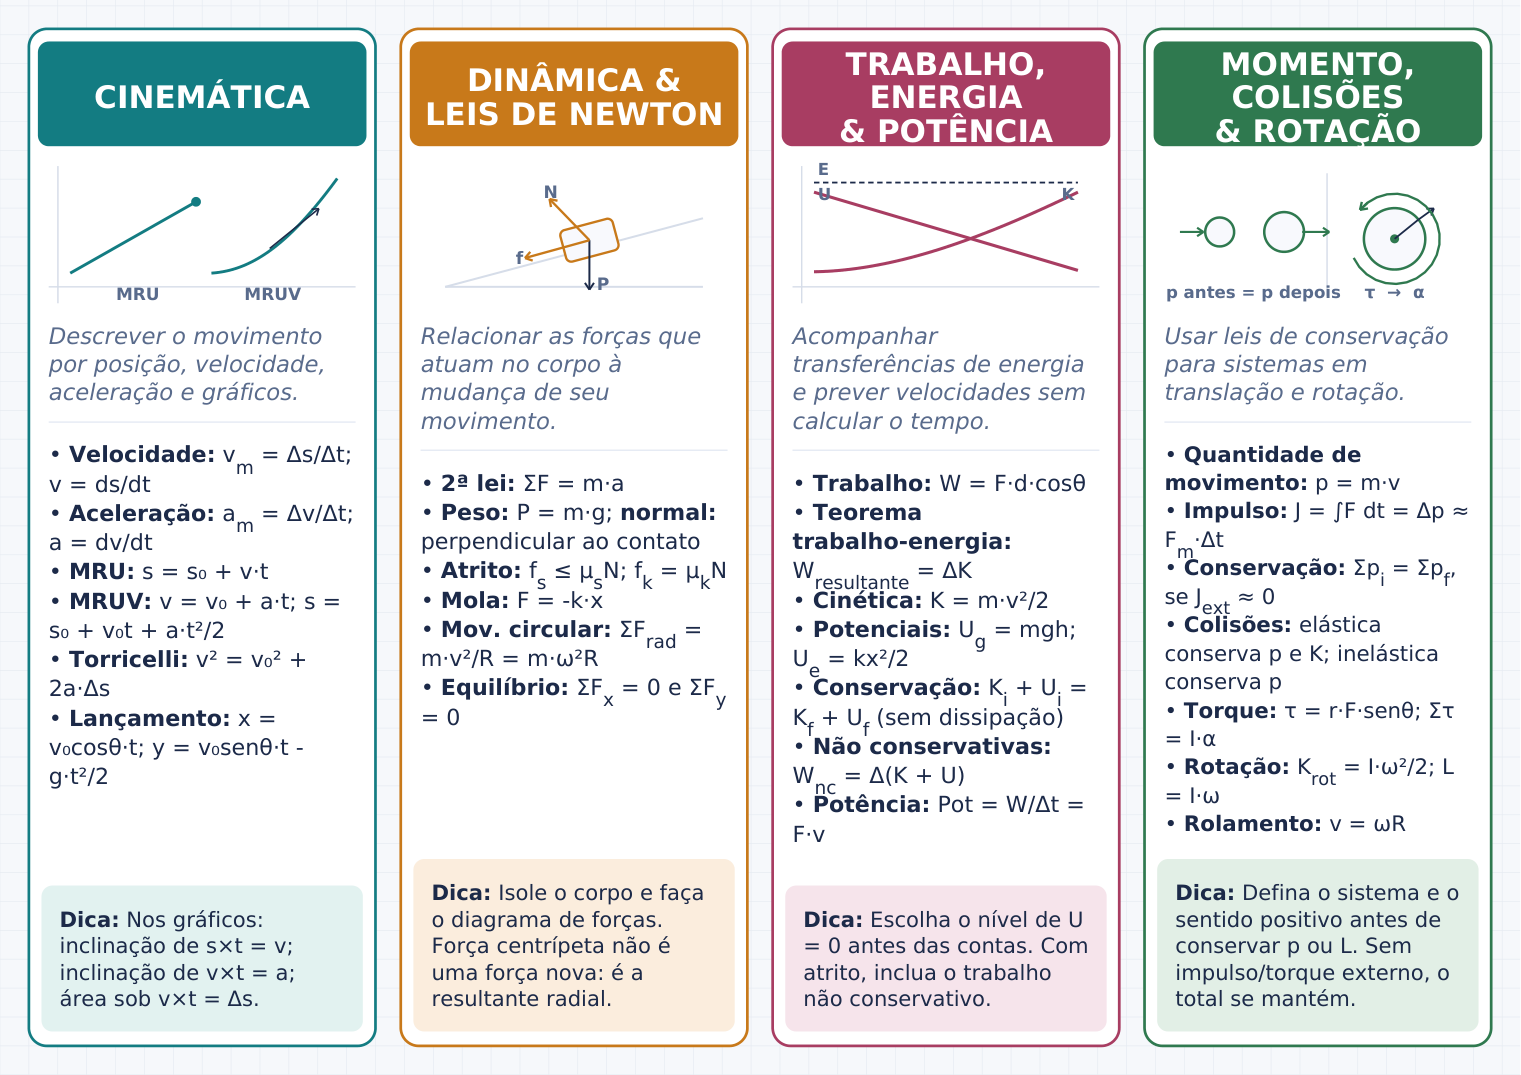

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Fisica_Geral_Experimental_Mecanica_Energia.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) MRUV: carro de 0 a 100 km/h em 8 s
   aceleracao = 3.47 m/s^2 | distancia = 111.1 m

2) QUEDA LIVRE do repouso, 45 m
   v_final = 29.71 m/s | tempo = 3.03 s

3) TRABALHO / ENERGIA: bloco de 10 kg em plano inclinado 30 graus
   trabalho da forca paralela (10 m) = 849.6 J | v (sem atrito) = 13.04 m/s

4) COLISAO INELASTICA: m1=2kg v1=6m/s ; m2=4kg v2=0
   v' = 2.00 m/s (conservacao de momento)

5) LANCAMENTO DE PROJETIL: v0=30 m/s, angulo 45 graus
   tempo total = 4.32 s | alcance = 91.7 m | altura max = 22.9 m


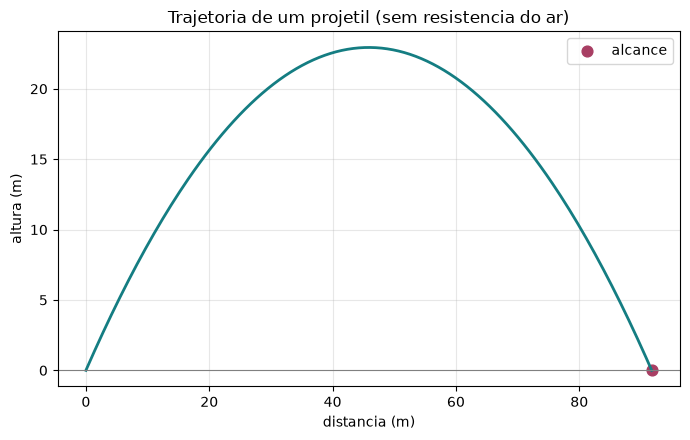


OK - cinematica e dinamica simuladas numericamente.


In [3]:

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

g = 9.81

print("=" * 60)
print("1) MRUV: carro de 0 a 100 km/h em 8 s")
v0, vf, dt = 0.0, 100/3.6, 8.0
a = (vf - v0)/dt
d = v0*dt + 0.5*a*dt**2
print(f"   aceleracao = {a:.2f} m/s^2 | distancia = {d:.1f} m")

print("\n2) QUEDA LIVRE do repouso, 45 m")
h = 45.0
v = np.sqrt(2*g*h)
tq = np.sqrt(2*h/g)
print(f"   v_final = {v:.2f} m/s | tempo = {tq:.2f} s")

print("\n3) TRABALHO / ENERGIA: bloco de 10 kg em plano inclinado 30 graus")
m = 10.0
theta = np.radians(30)
W = m*g*10*np.cos(theta)
K = W
v_energia = np.sqrt(2*K/m)
print(f"   trabalho da forca paralela (10 m) = {W:.1f} J | v (sem atrito) = {v_energia:.2f} m/s")

print("\n4) COLISAO INELASTICA: m1=2kg v1=6m/s ; m2=4kg v2=0")
m1, v1, m2, v2 = 2.0, 6.0, 4.0, 0.0
v_apos = (m1*v1 + m2*v2)/(m1 + m2)
print(f"   v' = {v_apos:.2f} m/s (conservacao de momento)")

print("\n5) LANCAMENTO DE PROJETIL: v0=30 m/s, angulo 45 graus")
v0, ang = 30.0, np.radians(45)
t_total = 2*v0*np.sin(ang)/g
alcance = v0*np.cos(ang)*t_total
altura = (v0*np.sin(ang))**2/(2*g)
print(f"   tempo total = {t_total:.2f} s | alcance = {alcance:.1f} m | altura max = {altura:.1f} m")

ts = np.linspace(0, t_total, 200)
x_t = v0*np.cos(ang)*ts
y_t = v0*np.sin(ang)*ts - 0.5*g*ts**2
plt.figure(figsize=(7, 4.5))
plt.plot(x_t, y_t, color="#147D82", lw=2)
plt.axhline(0, color="gray", lw=0.8)
plt.scatter([alcance], [0], color="#A83E63", s=60, label="alcance")
plt.title("Trajetoria de um projetil (sem resistencia do ar)")
plt.xlabel("distancia (m)"); plt.ylabel("altura (m)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("\nOK - cinematica e dinamica simuladas numericamente.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
